---

### eChem course module on:

# [Density Functional Theory](https://kthpanor.github.io/echem/dft/)

### [Patrick Norman](https://www.kth.se/profile/panor)

#### [KTH Royal Institute of Technology](https://www.kth.se/), Stockholm, Sweden

---

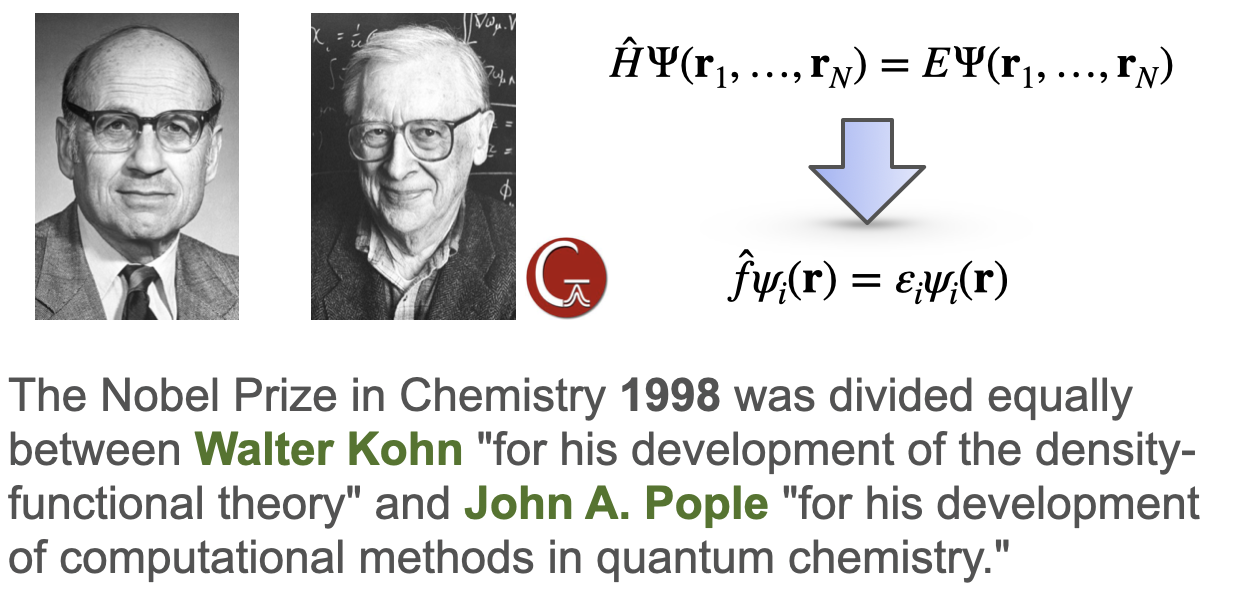

Let us consider an isolated molecular system with $N$ electrons. For the ground state, we have

\begin{equation*}
\hat{H} \Psi_0 = E_0 \Psi_0 
\end{equation*}

where $\hat{H}$ is composed of the kinetic energy, electron–electron repulsion, and external potential operators

\begin{equation*}
\hat{H} = \hat{T} + \hat{U} + \hat{V}
\end{equation*}

with

\begin{equation*}
\hat{T} =  - \frac{\hbar^2}{2 m_\mathrm{e}} \sum_{i=1}^N \nabla_i^2 ; \qquad
%
\hat{U} = \sum_{i=1}^N \sum_{j>i}^N
\frac{e^2}{4\pi\varepsilon_0 |\mathbf{r}_i -\mathbf{r}_j|} ; \qquad
%
\hat{V} = \sum_{i=1}^N \hat{v}(i)
\end{equation*}


For an isolated system, the latter reduces to the electron–nuclear attraction operator with a coordinate representation

$$
v(\mathbf{r}) = - \sum_{A=1}^M \frac{Z_A e^2}{4\pi\varepsilon_0 
|\mathbf{r} - \mathbf{R}_A|}
$$

where $Z_A$ is the proton number of atom $A$ in the system.

## [One-particle density](https://kthpanor.github.io/echem/reduced-density/#one-particle-density)

The one-particle density equals the probability density of finding *any one* electron at position $\mathbf{r}$ in space regardless of the positions of other electrons.

Expressed in terms of the many-electron wave function, we get

\begin{equation*}
n_0(\mathbf{r}) = N \int 
|\Psi_0(\mathbf{r}, \mathbf{r}_2,.., \mathbf{r}_N)|^2 
d^3\mathbf{r}_2 \cdots 
d^3\mathbf{r}_N
\end{equation*}

### [Single determinant state](https://kthpanor.github.io/echem/docs/elec_struct/operators.html#reduced-particle-density-operators)

The one-particle density for a Hartree–Fock state is equal to the sum of the occupied spin orbital densities

$$
n_0(\mathbf{r}) = \sum_{i=1}^N |\psi_i(\mathbf{r})|^2
$$

For a closed-shell state, we get

$$
n_0(\mathbf{r}) = n_0^\alpha(\mathbf{r}) + n_0^\beta(\mathbf{r}); \qquad
n_0^\alpha(\mathbf{r}) = n_0^\beta(\mathbf{r}) =
\sum_{i}^\mathrm{occ} |\phi_i(\mathbf{r})|^2
$$

where $\phi_i$ is a doubly occupied molecular orbital (MO).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import veloxchem as vlx

In [ ]:
co_xyz = """2
carbon monoxide
C        0.00000000    0.00000000    0.00000000
O        0.00000000    0.00000000    1.43
"""
molecule = vlx.Molecule.from_xyz_string(co_xyz)
basis = vlx.MolecularBasis.read(molecule, "cc-PVDZ")

scf_drv = vlx.ScfRestrictedDriver()
scf_results = scf_drv.compute(molecule, basis)

In [ ]:
vis_drv = vlx.VisualizationDriver()

# list of coordinates in units of Bohr
n = 2000
coords = np.zeros((n, 3))
z = np.linspace(-1, 4, n)
coords[:, 2] = z

one_part_den = vis_drv.get_density(coords, molecule, basis, scf_drv.density, "alpha")

In [ ]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(z, one_part_den, lw=2, label=r"$n^\alpha(\mathbf{r})$")

plt.setp(plt.gca(), xlim=(-1, 4))
plt.legend()

plt.xlabel(r"Internuclear axis coordinate (Bohr)")
plt.ylabel(r"One-particle density (a.u.)")

plt.subplot(1, 2, 2)
plt.plot(z, one_part_den, lw=2, label=r"$n^\alpha(\mathbf{r})$")
plt.plot(z, one_part_den, "ko")
plt.grid(True)

plt.setp(plt.gca(), xlim=(-0.05, 0.05), ylim=(50, 62))
plt.legend()

plt.xlabel(r"Internuclear axis coordinate (Bohr)")
plt.ylabel(r"One-particle density (a.u.)")

plt.show()

## [Hohenberg–Kohn theorems](https://kthpanor.github.io/echem/hohenberg/)

### [$v$-representability](https://kthpanor.github.io/echem/docs/elec_struct/hohenberg.html#)

The first attempts to describe ground states of atoms in terms of electron densities were made in the 1920s by Thomas and Fermi. But the use of the density as the primary variable to describe the electronic ground state was not legitimized until 1964, when Hohenberg and Kohn (HK) introduced their theorems for $v$-representable electron densities.

> An electron density is $v$-representable if it is associated with a ground-state solution to the Schrödinger equation.

Considering all possible variations in the external potential (system variations), we understand that there is an infinite number of $v$-representable densities associated with $N$-electron systems. We refer to a general density in this set as $\tilde{n}_0(\mathbf{r})$.

### [HK theorem I](https://kthpanor.github.io/echem/docs/elec_struct/hohenberg.html#hk-theorem-i)

> The external potential $\hat{v}(\mathbf{r})$ of a given system is determined to within a trivial additive constant by the $v$-representable electron density of the system.

In other words, there is a unique one-to-one mapping between a ground-state wave function and its one-electron density, and the knowledge of $n_0(\mathbf{r})$ is sufficient to determine the ground-state energy (and other ground-state properties) of the molecular system.

The energy functional is separated into two terms

$$
E_0 =
E[n_0(\mathbf{r})] =
F_\mathrm{HK}[n_0(\mathbf{r})] + V[n_0(\mathbf{r})]
$$

where

$$
V[n_0(\mathbf{r})] =
\int v(\mathbf{r}) n_0(\mathbf{r}) \, d^3\mathbf{r}
$$

and the Hohenberg–Kohn functional is introduced as the sum of kinetic and electron repulsion energies

$$
F_\mathrm{HK}[n_0(\mathbf{r})] = T[n_0(\mathbf{r})] + U[n_0(\mathbf{r})]
$$ 

The HK functional is universal in the sense that it does not depend on the system under study and it is left undefined for densities that are not $v$-representable.

### [HK theorem II](https://kthpanor.github.io/echem/docs/elec_struct/hohenberg.html#hk-theorem-ii)

> From the $v$-representable trial densities $\tilde{n}_0(\mathbf{r})$ fulfilling
>
> \begin{equation*}
\int \tilde{n}_0(\mathbf{r}) \, d^3\mathbf{r} = N ;
\qquad
\tilde{n}_0(\mathbf{r}) \geq 0
\end{equation*}
>
> the ground state energy $E_0$ of a molecular system can be detemined from the relation
>
> \begin{equation*}
 E_0 \leq E[\tilde{n}_0(\mathbf{r})]
\end{equation*}

We recognize this relation as the variational principle in wave function theory. Any practical application of this relation in density functional theory is, however, severely hampered by the fact that it is prohibitively difficult to ensure that density variations remain $v$-representable. 

### [$N$-representability](https://kthpanor.github.io/echem/docs/elec_struct/hohenberg.html#n-representability)

The theory can be reformulated on the grounds of the Hohenberg–Kohn theorems but for the wider class of so-called $N$-representable densities.

> An electron density is $N$-representable if it can be obtained from some anti-symmetric wave function. Such a density satisfies the following conditions 
\begin{equation*}
\int n(\mathbf{r}) \, d^3\mathbf{r} = N ; \quad  
n(\mathbf{r}) \geq 0; \quad 
\int \left| \nabla n(\mathbf{r})^{1/2}  \right|^{2} \, d^3\mathbf{r}  \leq \infty
\end{equation*}

For a given $N$-representable density, Levy demonstrated that 

$$
F[n(\mathbf{r})] + V[n(\mathbf{r})] \geq E_0
$$

which implies a variational principle with respect to $N$-representable densities. 

## [Kohn–Sham method](https://kthpanor.github.io/echem/kohn-sham/)

Early attempts to employ density functional theory for electronic structure investigations of atoms led to relatively poor results due to inaccurate approximations of the kinetic energy term in the functional $F$. 

In 1965, Kohn and Sham proposed a solution to this problem by introducing the concept of Kohn–Sham (KS) orbitals and evaluating the kinetic energy according to

\begin{equation*}
T_s[n(\mathbf{r})] = - \frac{\hbar^2}{2 m_\mathrm{e}}
\sum_{i=1}^N \int  \psi_i^*(\mathbf{r}) \nabla^2  \psi_i(\mathbf{r}) \, d^3\mathbf{r}  
\end{equation*}

where the electron density is defined as

\begin{equation*}
n(\mathbf{r}) = \sum_{i=1}^N | \psi_i(\mathbf{r})|^2 
\end{equation*}

To within a small residual correction, the functional $T_s$ amounts to the true kinetic energy functional $T$. 

### Kohn–Sham reference state

Underlying this idea, there is a representation of the electronic ground state in terms of a Slater determinant known as the Kohn–Sham reference state

\begin{equation*}
| \Psi_s \rangle = \frac{1}{\sqrt{N!}} \det \big[\psi_1 \psi_2\cdots\psi_N\big]
\end{equation*}

which ensures that the density is $N$-representable.

Correspondingly, the energy functional can be written

\begin{equation*}
E[n(\mathbf{r})] = T_s[n(\mathbf{r})] + J[n(\mathbf{r})] + E_\mathrm{xc}[n(\mathbf{r})] + \int v(\mathbf{r}) n(\mathbf{r}) \, d^3\mathbf{r}
\end{equation*}

where the electron–electron interaction contribution is partitioned into the classical Coulomb interaction energy

$$
J[n(\mathbf{r})] = 
\frac{1}{2}
\frac{e^2}{4\pi\varepsilon_0}
\int\int
\frac{n(\mathbf{r}) n(\mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|}
\, d^3\mathbf{r} \, d^3\mathbf{r}'
$$ 

and the exchange–correlation (XC) functional, $E_\mathrm{xc}[n(\mathbf{r})]$, accounting for the non-classical electron–electron interaction and the residual kinetic energy correction.

### Kohn–Sham equation

Within the Kohn–Sham formulation of DFT, the act of minimizing the energy under the constraint of particle conservation closely follows the derivation of the Hartree–Fock equation and the resulting equation from which the best orbitals are found is known as the Kohn–Sham equation. In its canonical form, it reads

$$
\hat f \psi_i(\mathbf{r}) = \left[ -\frac{\hbar^2}{2 m_\mathrm{e}} \nabla^2 + v_\mathrm{eff}(\mathbf{r}) \right] \psi_i(\mathbf{r}) = \varepsilon_i \psi_i(\mathbf{r})
$$

where $\varepsilon_i$ is the KS orbital energy and $v_\mathrm{eff}(\mathbf{r})$ is the effective potential equal to

$$
v_\mathrm{eff}(\mathbf{r}) = 
\frac{e^2}{4\pi\varepsilon_0}
\int \frac{n(\mathbf{r'})}{|\mathbf{r} - \mathbf{r}'|} 
\, d^3\mathbf{r}' 
+ v_\mathrm{xc}(\mathbf{r})
+ v(\mathbf{r})
$$

with

$$
v_\mathrm{xc}(\mathbf{r}) = \frac{\delta E_{xc}}{\delta n(\mathbf{r})}
$$

## [Exchange–correlation functionals](https://kthpanor.github.io/echem/kohn-sham/#exchange-correlation-functionals)

The accuracy  of the Kohn-Sham method is determined by the capability of the XC functional to capture the non-classical electron–electron interactions in the molecular system. As the exact form of XC functional is unknown, one introduces physically justified approximations.

We will assume the XC functional to be written on the form

$$
E_\mathrm{xc}[n(\mathbf{r})] = \int
n(\mathbf{r}) \,
\varepsilon_\mathrm{xc}(n, \nabla n, \nabla^2 n) \, d^3\mathbf{r} 
$$

where it is implicitly understood that the electron density can be decomposed into $\alpha$- and $\beta$-spin densities that in general may not be equal. 

LDA functionals depend solely on $n(\mathbf{r})$. Within LDA, the combination of the Dirac exchange and the Vosko-Wilk-Nussair correlation functionals provides the most accurate results in a wide range of applications and it has become recognized as the *de facto* standard LDA functional.

In the LDA, the exchange–correlation potential takes the form

$$
v_\mathrm{xc}(\mathbf{r}) =
\varepsilon_\mathrm{xc}(n(\mathbf{r})) + n(\mathbf{r})
\frac{\partial \varepsilon_\mathrm{xc}}{\partial n}
$$

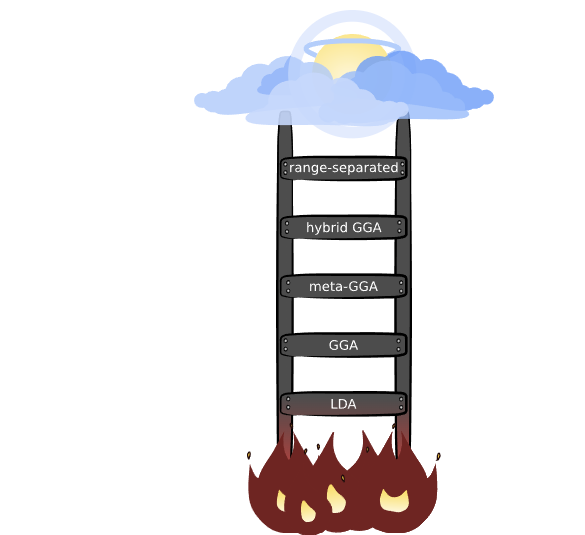

## [Kernel integration](https://kthpanor.github.io/echem/kernel-int/)

In DFT, the exchange–correlation kernel integrations are performed numerically

$$
E_\mathrm{xc}[n(\mathbf{r})] = \int
n(\mathbf{r}) \,
\varepsilon_\mathrm{xc}(n, \nabla n, \nabla^2 n) \, d^3\mathbf{r} 
\approx
\sum_{g=1}^P
w_g \,
n(\mathbf{r}_g) \,
\varepsilon_\mathrm{xc}(n, \nabla n, \nabla^2 n)
\,\Big|_{\mathbf{r} = \mathbf{r}_g}
$$

In VeloxChem, the set of grid points and the associated grid-point weights, $w_i$ are constructed using modified versions of the Log3-quadrature and SSF-partitioning schemes. In practical work, the number of grid points, $P$, amounts to in the order of $10^6$.

Integration of the density itself results in the number of electrons in the system

$$
\int n(\mathbf{r}) \, d^3\mathbf{r} = N
$$

Let us use this as a test of the accuracy in the numerical integration.

### [Molecular grid points](https://kthpanor.github.io/echem/docs/elec_struct/kernel_int.html#molecular-grid-points)

In [ ]:
grid_drv = vlx.GridDriver()

grid_drv.set_level(4)  # default level in VeloxChem
molgrid = grid_drv.generate(molecule)

# weights of grid points
weights = molgrid.w_to_numpy()

# grid point coordinates
x = molgrid.x_to_numpy()
y = molgrid.y_to_numpy()
z = molgrid.z_to_numpy()

P = molgrid.number_of_points()
print("Number of grid points:", P)

#### Spatial distribution of grid points

In [ ]:
grid_xyz = "\nGrid points\n"

r = np.sqrt(x**2 + y**2 + z**2)

au2ang = 0.52911721

i = 0
for g in range(P):
    if r[g] > 5.0:
        grid_xyz += f"He {x[g] * au2ang : 16.8f} {y[g] * au2ang : 16.8f} {z[g] * au2ang : 16.8f}\n"
        i += 1

grid_xyz = str(i) + grid_xyz

print("Number of grid point outside sphere:", i)
print("Number of grid point inside sphere:", P - i)

Not surprisingly, the grid point density is much larger inside the van der Waals volume of the molecule where the electron density is large.

Let us visualize all grid points outside the sphere of radius 5.0 $a_0$.

In [ ]:
import py3Dmol as p3d

v = p3d.view(width=400, height=400)

v.addModel(co_xyz, "xyz")
v.setStyle({"sphere": {}})

v.addModel(grid_xyz, "xyz")
v.setStyle({"elem": "He"}, {"sphere": {"radius": 0.05, "color": "red", "opacity": 0.5}})

# rotate for a better initial view
v.rotate(90, "y")

v.zoomTo()

v.show()

### [Density on grid points](https://kthpanor.github.io/echem/docs/elec_struct/kernel_int.html#density-on-grid-points)

In [ ]:
D = scf_results["D_alpha"] + scf_results["D_beta"]

In [ ]:
xc_drv = vlx.XCIntegrator()

chi_g = xc_drv.compute_gto_values(molecule, basis, molgrid)

print(chi_g.shape)

$$
n(\mathbf{r}_g) = \sum_{\alpha,\beta} 
\chi^*_\alpha(\mathbf{r}_g)
D_{\alpha\beta} 
\chi_\beta(\mathbf{r}_g)
$$

### <font color="green"> Example </font>
    
---

Determine the number of electrons by numerical integration.

In [ ]:
n = np.einsum("ag,ab,bg->g", chi_g, D, chi_g)

In [ ]:
N = np.einsum("g,g", weights, n)

print(f"Number of electrons: {N : 16.12f}")

---

**Integrals in AO basis**

In [ ]:
# overlap matrix
S = vlx.compute_overlap_integrals(molecule, basis)
T = vlx.compute_kinetic_energy_integrals(molecule, basis)
V = vlx.compute_nuclear_potential_integrals(molecule, basis)

h = T + V

fock_drv = vlx.FockDriver()
g = fock_drv.compute_eri(molecule, basis)

## [Writing your own Kohn–Sham SCF program](https://kthpanor.github.io/echem/dft-scf/)

### Exchange–correlation functional

Let us assume that the exchange–correlation functional merely includes [Slater exchange](https://en.wikipedia.org/wiki/Local-density_approximation#Exchange_functional)

$$
\varepsilon_\mathrm{xc}(n(\mathbf{r})) =
-\frac{3}{4} \Big(\frac{3}{\pi}\Big)^{1/3} \big[n(\mathbf{r})\big]^{1/3}
$$

We get

$$
v_\mathrm{xc}(\mathbf{r}) = \frac{4}{3} \varepsilon_\mathrm{xc}(n(\mathbf{r}))
$$

### Reference calculation

In [ ]:
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "slater"
scf_results = scf_drv.compute(molecule, basis)

In [ ]:
C_LDA = scf_results["C_alpha"]

In [ ]:
norb = basis.get_dimensions_of_basis()
nocc = molecule.number_of_alpha_electrons()
V_nuc = molecule.nuclear_repulsion_energy()

print("Number of contracted basis functions:", norb)
print("Number of doubly occupied molecular orbitals:", nocc)
print(f"Nuclear repulsion energy (in a.u.): {V_nuc : 14.12f}")

### XC contribution to Fock matrix

The contrbutions from $\hat{v}_\mathrm{xc}$ to the Fock operator in the AO matrix representation will be obtained by means of numerical integration. 

$$
F^\mathrm{xc}_{\alpha\beta} = 
( \chi_\alpha | \hat{v}_\mathrm{xc} | \chi_\beta ) \approx
\sum_{g=1}^P
w_g \,
\chi_\alpha^\ast(\mathbf{r}_g) 
v_\mathrm{xc}(\mathbf{r}_g)
\chi_\beta(\mathbf{r}_g)
$$

In [ ]:
def LDA_exchange(D):
    F_xc = np.zeros((norb, norb))

    n = np.einsum("ag,ab,bg->g", chi_g, D, chi_g)

    e_xc = -0.75 * (3 / np.pi) ** (1 / 3) * n ** (1 / 3)
    E_xc = np.einsum("g,g", weights, n * e_xc)

    v_xc = -((3 / np.pi) ** (1 / 3)) * n ** (1 / 3)

    for alpha in range(norb):
        for beta in range(alpha, norb):
            F_xc[alpha, beta] = np.sum(weights * chi_g[alpha,:] * v_xc * chi_g[beta,:])
            F_xc[beta, alpha] = F_xc[alpha, beta]

    return F_xc, E_xc

### SCF iterations

In [ ]:
max_iter = 50
conv_thresh = 1e-6

In [ ]:
C = C_LDA  # initial guess

In [ ]:
print("iter       SCF energy   LDA exchange   Error norm")

for iter in range(max_iter):

    D = 2 * np.einsum("ai,bi->ab", C[:, :nocc], C[:, :nocc])
    J = np.einsum("abcd,cd->ab", g, D)

    F = h + J  # no exact exchange in the Fock matrix

    F_xc, E_xc = LDA_exchange(D)
    F += F_xc  # add LDA exchange

    E = np.einsum("ij,ij->", h + 0.5 * J, D) + V_nuc
    E += E_xc

    F_MO = np.einsum("ai,ab,bj->ij", C, F, C)  # compute convergence metric
    e_vec = np.reshape(F_MO[:nocc, nocc:], -1)
    error = np.linalg.norm(e_vec)

    print(f"{iter:>2d} {E:18.8f} {E_xc:14.8f} {error:12.2e}")

    if error < conv_thresh:
        print("SCF iterations converged!")
        break

    epsilon, C = scipy.linalg.eigh(F, S)

## [Self-interaction error](https://kthpanor.github.io/echem/dft-scf/#self-interaction-error)

In Hartree–Fock, the exchange energy equals

$$
E_{\mathrm{x}}^\mathrm{HF} = - \sum_{i=1}^{N/2} K_{ii}
; \qquad
K_{ii} = \sum_{j=1}^{N/2}
( \phi_i \phi_j | \phi_j \phi_i )
$$

The term in $K_{ii}$ with $j = i$ cancels the self-interaction in the classical Coulomb electron repulsion energy. In DFT, with an approximate form of the exchange–correlation energy functional, this cancelation is no longer guaranteed.

In [ ]:
K = 0.5 * np.einsum("adcb,cd->ab", g, D)
HF_x = 0.5 * np.einsum("ab,ab->", -K, D)

print(f"LDA exchange  : {E_xc : 16.12f}")
print(f"Exact exchange: {HF_x : 16.12f}")

In [ ]:
LDA_x_ii = []
HF_x_ii = []
g_iiii = []

for i in range(nocc):
    LDA_x_ii.append(1.5 * np.einsum("a,b,ab->", C[:, i], C[:, i], F_xc))
    HF_x_ii.append(-np.einsum("a,b,ab->", C[:, i], C[:, i], K))
    g_iiii.append(-np.einsum("a,b,c,d,abcd->", C[:, i], C[:, i], C[:, i], C[:, i], g))

### Orbital-specific exchange 

In [ ]:
fig = plt.figure(figsize=(8, 6))

ax = plt.axes(xticks=range(nocc), ylim=(-5.2, 0))

ax.scatter(range(nocc), HF_x_ii, label="Exact exchange")
ax.scatter(range(nocc), LDA_x_ii, label="LDA exchange")
ax.scatter(range(nocc), g_iiii, label=r"$-(\phi_i\phi_i | \phi_i\phi_i)$")

ax.legend(fontsize=12)
ax.grid(True)

plt.xlabel("Molecular orbital", fontsize=12)
plt.ylabel("Energy (Hartree)", fontsize=12)

plt.show()

First, we note that the self-interaction energy (SIE) in terms of the integral $(\phi_i\phi_i|\phi_i\phi_i)$ represents a dominant part of the exchange energy. The percentage contributions exceed 60% for all orbitals and it reaches 97% for the core $1s$-orbital.

In [ ]:
print("SIE percentage part of exchange energy")
for i in range(nocc):
    print(f"{i} {g_iiii[i] / HF_x_ii[i] * 100 : 6.1f}%")

Second, we note that the LDA exchange energy is closely equal to the exact Hartree–Fock exchange energy for the outer valence orbitals but substantially less so for the core and inner valence orbitals.

In [ ]:
print("Comparison of LDA and HF exchange energies")
for i in range(nocc):
    print(
        f"{i} {LDA_x_ii[i] / HF_x_ii[i] * 100 : 6.1f}% {LDA_x_ii[i] - HF_x_ii[i] : 6.2f} a.u."
    )

## <font color="green">Summary</font>

- The Kohn–Sham formulation of DFT takes a very similar SCF form compared to Hartree–Fock
- The exchange operator is replaced with the exchange–correlation potential
- The DFT kernel integration is performed numerically
- DFT introduces self-interaction errors that are large for core electrons

**End of DFT**